# Computing energy histogram and specific test images

In [1]:
%load_ext autoreload
%autoreload 2

from noise import *
from pathlib import Path 
import json
from data import *
from trackers import *
from main import *

from covariance_generation import *

from networks.conditioning import *

import lpips

seed = 20
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Load model

In [2]:
def load_args(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    return args_dict


def load_exp(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    args_dict['size_network'] = "large"

    ctx = TrainingContext(**args_dict, step=step, key_remap=None, seed=None, dataloaders=dataloaders, writer=False)
    if log:
        print(f"{name}: retrieved model at step {ctx.step}")

    # Disable DataParallel (needed for Hessian computation)
    # ctx.model.network = ctx.model.network.module
    # === APPLY EMA HERE ===
    if getattr(ctx, "ema_loaded_from_checkpoint", False):
        ctx.ema.apply_shadow(ctx.network)
        
    # Put in eval mode and disable gradients with respect to all parameters.
    ctx.model.eval()
    for p in ctx.model.parameters():
        p.requires_grad = False

    # Normalize energies.
    # ctx.network.network.log_normalization_constant = ctx.test_perf.log_normalization_constant

    return ctx

def get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dis):
    if sigma_dist == 'geometric':
        sigmas = torch.tensor(
            np.exp(np.linspace(np.log(sigma_begin), np.log(sigma_end),
                               num_classes))).float().to(device)
    elif sigma_dist == 'uniform':
        sigmas = torch.tensor(
            np.linspace(sigma_begin, sigma_end, num_classes)
        ).float().to(device)

    else:
        raise NotImplementedError('sigma distribution not supported')

    return sigmas

torch.set_default_dtype(torch.float32)
    # torch.set_printoptions(precision=10, sci_mode=False)

# args = load_args("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda0_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "best")
args = load_args("multigpu/all_together/energy_song_dual_truncatedFreq_celeba", step = "best")
# args = load_args("multigpu/inpainting_celeba/energy_song_autoregressive_Celeba", step = "best")
# args = load_args("multigpu/combined_cov_tworandvars/energy_songWavelet_anisoEmb_groupNorm_lambda1_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "last")
step = "last"
ctxs = {
            "Energy-Dual": load_exp("multigpu/all_together/energy_song_dual_truncatedFreq_celeba", step = step),
        }

default_ctx = ctxs["Energy-Dual"]
device = default_ctx.device
dataset_info = default_ctx.dataset_info
d = dataset_info.dimension


# Load data
test_batch_size = 16
H = 64
CHW = 3 * H * H

train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=8, seed=20
)

images = next(iter(test_dataloader))  # load for testing things.

shape = (images[0].shape[0], CHW)

time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")


loss_fn_alex = lpips.LPIPS(net='alex').cuda() # best forward scores

False
[EMA LOAD] 'ema' NOT in checkpoint (use_ema=True)
multigpu/all_together/energy_song_dual_truncatedFreq_celeba: retrieved model at step 400000
Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/lpips/weights/v0.1/alex.pth


## Celeba

## Compute p_xy for all the images for each y

In [ ]:
n_files = 10 #10
batch_size = 32 #32
path = "samples/Celeba_45_0.02posterior_exp10_PC_pixel"
path_dps =  "../CovarianceEDMScoreMatching/samples/Celeba_45_dps_pixelposterior_exp10"
path_reddiff = "../CovarianceEDMScoreMatching/samples/Celeba_45_reddiff_pixelposterior_exp10"
path_adaptive = None

sigma_box = 1e-3 #1e-4
sigma_clean_init = 1e-3 #1e-3
domain = 'pixel' #'freq' #
inp_mask_type = "box"
box_size = 45 #45 #21 #13
img_size = H

energy_values = torch.zeros(n_files * batch_size)
energy_post = torch.zeros(n_files * batch_size)
entropy_y = torch.zeros(n_files * batch_size)
entropy_x = torch.zeros(n_files * batch_size)
mse = torch.zeros(n_files * batch_size)
imgs = torch.zeros(n_files * batch_size, 3, 64, 64)
likelihood = torch.zeros(n_files * batch_size)

energy_values_adaptive = torch.zeros(n_files * batch_size)
entropy_x_adaptive = torch.zeros(n_files * batch_size)
mse_adaptive = torch.zeros(n_files * batch_size)
imgs_adaptive = torch.zeros(n_files * batch_size, 3, 64, 64)
likelihood_entropy_adaptive = torch.zeros(n_files * batch_size)

energy_values_dps = torch.zeros(n_files * batch_size)
entropy_x_dps = torch.zeros(n_files * batch_size)
mse_dps = torch.zeros(n_files * batch_size)
imgs_dps = torch.zeros(n_files * batch_size, 3, 64, 64)
likelihood_entropy_dps = torch.zeros(n_files * batch_size)

energy_values_red = torch.zeros(n_files * batch_size)
entropy_x_red = torch.zeros(n_files * batch_size)
mse_red = torch.zeros(n_files * batch_size)
imgs_red = torch.zeros(n_files * batch_size, 3, 64, 64)
likelihood_entropy_red = torch.zeros(n_files * batch_size)

    
def compute_entropy(x_input, covariance, model, sigma):
    noise_level = NoiseLevel(variance=sigma**2)
    input = ModelInput(noisy=x_input.cuda(), noise_level=noise_level, covariance=covariance)
    model_output = model.forward(input, create_graph = False)

    return -model_output.energy

def compute_log_likelihood(x_input, y, mask, covariance, CHW = 12288, sigma_noise = 1e-3):
    likelihood = apply_power_to_list_covariances(covariance, y - apply_power_to_list_covariances(mask, x_input.cuda(), p =1) , p=-0.5)
    total_likelihood = -torch.sum(likelihood ** 2, dim=(-1, -2, -3)).to('cpu')

    total_likelihood = total_likelihood - (CHW / 2) * np.log(2 * np.pi * sigma_noise**2)

    # print(total_likelihood.shape)
    return total_likelihood
        

for bs in range(n_files):
    saved_outputs = torch.load(f"{path}/samples_posterior_{bs}.pt")
    y_ours = saved_outputs['y']# + 0.01 * torch.randn_like(saved_outputs['y'])
    x_hat = saved_outputs['samples']

    if path_adaptive is not None:
        saved_outputs_adaptive = torch.load(f"{path_adaptive}/samples_posterior_{bs}.pt")
        x_mod_adaptive = saved_outputs_adaptive['samples']

    if path_dps is not None:
        saved_outputs_dps = torch.load(f"{path_dps}/samples_posterior_{bs}.pt")
        x_mod_dps = saved_outputs_dps['samples']
    if path_reddiff is not None:
        saved_outputs_red = torch.load(f"{path_reddiff}/samples_posterior_{bs}.pt")
        x_mod_red = saved_outputs_red['samples']
    # covariance = []
    mask = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=0, device=device, var_clean = 1, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
    with torch.no_grad():

        # Compute entropy of our model #
        covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=sigma_box**2, device=device, var_clean = sigma_box**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
        entropy_x[bs*batch_size:bs*batch_size+batch_size] = compute_entropy(x_hat.cuda(), covariance, ctxs["Energy-Dual"].model, sigma = 0)        

        covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=10**2, device=device, var_clean = 1e-3**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
        entropy_y[bs*batch_size:bs*batch_size+batch_size] = compute_entropy(y_ours.cuda(), covariance, ctxs["Energy-Dual"].model, sigma = 0)  
        
        covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=1e-3**2, device=device, var_clean = 1e-3**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
        likelihood[bs*batch_size:bs*batch_size+batch_size] = compute_log_likelihood(x_hat, y_ours, mask, covariance)
        # print(likelihood)
        # energy_post[bs*batch_size:bs*batch_size+batch_size] = e - energy_values[bs*batch_size:bs*batch_size+batch_size] #logp + logp
        mse[bs*batch_size:bs*batch_size+batch_size] = torch.mean((saved_outputs['x'].repeat(batch_size,1,1,1) - x_hat.cuda())**2, dim=(-1, -2, -3))
        imgs[bs*batch_size:bs*batch_size+batch_size, : ,:,:] = x_hat

        # Compute entropy of DPS #
        if path_adaptive is not None:
            covariance_adaptive = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=sigma_box**2, device=device, var_clean = sigma_clean_init**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
            entropy_x_adaptive[bs*batch_size:bs*batch_size+batch_size] = compute_entropy(x_mod_adaptive.cuda(), covariance_adaptive, ctxs["Energy-Dual"].model, sigma = 0)        
            
            covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=1e-3**2, device=device, var_clean = 1e-3**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
            likelihood_entropy_adaptive[bs*batch_size:bs*batch_size+batch_size] = compute_log_likelihood(x_mod_adaptive, y_ours, mask, covariance)
    
            # mse_dps[bs*batch_size:bs*batch_size+batch_size] = torch.mean((saved_outputs_dps['x'].repeat(batch_size,1,1,1) - x_mod_dps.cuda())**2, dim=(-1, -2, -3))
            imgs_adaptive[bs*batch_size:bs*batch_size+batch_size, : ,:,:] = x_mod_adaptive

        # Compute entropy of DPS #
        if path_dps is not None:
            covariance_dps = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=sigma_box**2, device=device, var_clean = sigma_clean_init**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
            entropy_x_dps[bs*batch_size:bs*batch_size+batch_size] = compute_entropy(x_mod_dps.cuda(), covariance_dps, ctxs["Energy-Dual"].model, sigma = 0)        
            
            covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=1e-3**2, device=device, var_clean = 1e-3**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
            likelihood_entropy_dps[bs*batch_size:bs*batch_size+batch_size] = compute_log_likelihood(x_mod_dps, y_ours, mask, covariance)
            # print(likelihood_entropy_dps)
            mse_dps[bs*batch_size:bs*batch_size+batch_size] = torch.mean((saved_outputs_dps['x'].repeat(batch_size,1,1,1) - x_mod_dps.cuda())**2, dim=(-1, -2, -3))
            imgs_dps[bs*batch_size:bs*batch_size+batch_size, : ,:,:] = x_mod_dps

        # Compute entropy of RED #
        if path_reddiff is not None:
            covariance_red = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=sigma_box**2, device=device, var_clean = sigma_clean_init**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
            entropy_x_red[bs*batch_size:bs*batch_size+batch_size] = compute_entropy(x_mod_red.cuda(), covariance_red, ctxs["Energy-Dual"].model, sigma = 0)        
            
            covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=1e-3**2, device=device, var_clean = 1e-3**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
            likelihood_entropy_red[bs*batch_size:bs*batch_size+batch_size] = compute_log_likelihood(x_mod_red, y_ours, mask, covariance)
    
            mse_red[bs*batch_size:bs*batch_size+batch_size] = torch.mean((saved_outputs_red['x'].repeat(batch_size,1,1,1) - x_mod_red.cuda())**2, dim=(-1, -2, -3))
            imgs_red[bs*batch_size:bs*batch_size+batch_size, : ,:,:] = x_mod_red

## Compute ground-truth

In [ ]:
x_aux = saved_outputs['x'][None, :, :, :].detach()
x_true = torch.clamp(x_aux.clone() + 0.5e-3 * torch.randn_like(x_aux), 0, 1 )
# x_true = torch.clamp(torch.ones_like(x_aux), 0, 1)
batch_size = 1
covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=45, var_box=sigma_box**2, device=device, var_clean = sigma_box**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
noise_level = NoiseLevel(variance=0**2)
input = ModelInput(noisy=x_true.cuda(), noise_level=noise_level, covariance=covariance)
model_output = ctxs["Energy-Dual"].model.forward(input, create_graph = False)
logp_true = -model_output.energy

print(logp_true)

covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=1e-3**2, device=device, var_clean = 1e-3**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
likelihood_true = apply_power_to_list_covariances(covariance,saved_outputs['y'] - apply_power_to_list_covariances(mask, x_true.cuda(), p =1) , p=-0.5) / 2
likelihood_x_true = -torch.sum(likelihood_true ** 2, dim=(-1, -2, -3)).to('cpu')

x_true = torch.clamp(torch.ones_like(x_aux).cuda(),0, 1)#  + 0.5e-3 * torch.randn_like(x_aux), 0, 1 )
batch_size = 1
covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=64, var_box=sigma_box**2, device=device, var_clean = sigma_box**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
noise_level = NoiseLevel(variance=0**2)
input = ModelInput(noisy=x_true.cuda(), noise_level=noise_level, covariance=covariance)
model_output = ctxs["Energy-Dual"].model.forward(input, create_graph = False)
logp_constant = -model_output.energy

x_true = torch.clamp(torch.rand_like(x_aux).cuda(), 0, 1 )
batch_size = 1
covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=64, var_box=sigma_box**2, device=device, var_clean = sigma_box**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
noise_level = NoiseLevel(variance=0**2)
input = ModelInput(noisy=x_true.cuda(), noise_level=noise_level, covariance=covariance)
model_output = ctxs["Energy-Dual"].model.forward(input, create_graph = False)
logp_random = -model_output.energy

print(logp_random)

tensor([11619.9941], device='cuda:0', grad_fn=<NegBackward0>)
tensor([-38300.7539], device='cuda:0', grad_fn=<NegBackward0>)


## Compute constant

In [6]:
def compute_energy(x_input, covariance, model, sigma):
    noise_level = NoiseLevel(variance=sigma**2)
    input = ModelInput(noisy=x_input.cuda(), noise_level=noise_level, covariance=covariance)
    model_output = model.forward(input, create_graph = False)
    # energy_values[bs*batch_size:bs*batch_size+batch_size] = model_output.energy # log p(x_0)
    # c = lambda e: LogTensor(e, CHW).to(base="dBs", sign="logp", per_dimension=True)
    # logp = c(model_output.energy)
    # entropy_x[bs*batch_size:bs*batch_size+batch_size] = -model_output.energy#logp

    return model_output.energy


train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=20, num_workers=8, seed=20
)


img_size = H
energy_t = 0
t = 1e3
for batch_idx, images in enumerate(test_dataloader):

    y = images[0] + np.sqrt(t) * torch.randn_like(images[0])
    y = torch.clamp(y, 0, 1)
    batch_size = y.shape[0]
    covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=45, var_box=t, device=device, var_clean = t, half_box_size = 45, inp_mask_type="box")] * batch_size

    with torch.no_grad():
        energy_t = energy_t + compute_energy(y, covariance, ctxs["Energy-Dual"].model, sigma = 1e3).sum()

    if batch_idx % 50 == 0 and batch_idx > 0:
        break
print((batch_idx + 1) * batch_size, batch_idx, batch_size)
energy_t_mean = energy_t / ((batch_idx + 1) * batch_size) 
constants = (CHW) /2 * np.log(2 * np.pi * np.e * t) - energy_t_mean

print(constants)

Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)
1020 50 20
tensor(59882.5938, device='cuda:0')


## Plot

tensor(25.8945)
tensor(18.2669)


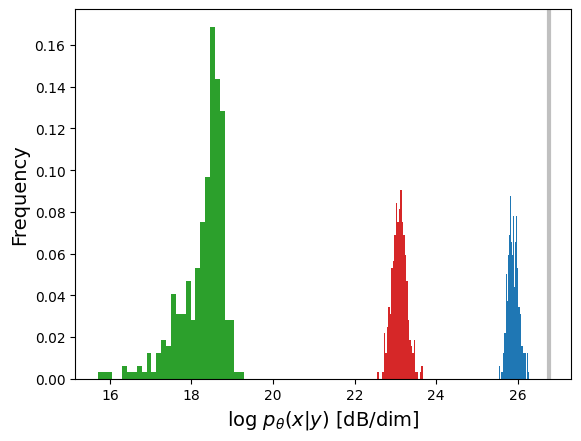

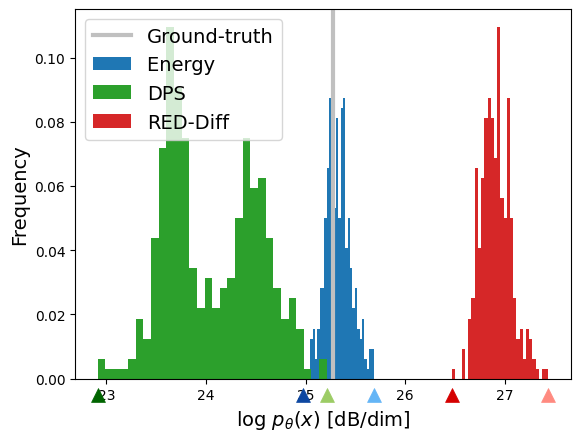

In [19]:
p_xy = (likelihood_x_true.cuda() + logp_true.cuda() - entropy_y[0].cuda() - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
log10p_xy = (10.0 / np.log(10)) * p_xy
# print(log10p_xy / CHW)

bins = 30
plt.figure(1)
plt.axvline(x = log10p_xy.detach().cpu().numpy() / CHW, label = "Ground-truth", linewidth=3, color = 'silver')
# plt.hist(log10p_xy.cpu().numpy() / CHW, label = "True p(x|y)", bins = bins, weights=np.ones(len(p_xy.detach().cpu().numpy())) / len(p_xy.detach().cpu().numpy()))

p_xy_hat_energy = (10.0 / np.log(10)) * (likelihood + entropy_x - entropy_y)# - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
p_xy_hat_energy = p_xy_hat_energy / CHW
plt.hist(p_xy_hat_energy.cpu().numpy(), label = "Energy", bins = bins, weights=np.ones(len(p_xy_hat_energy.detach().cpu().numpy())) / len(p_xy_hat_energy.detach().cpu().numpy()), color = 'tab:blue')
print(p_xy_hat_energy.mean())

if path_adaptive is not None:
    p_xy_hat_adaptive = (10.0 / np.log(10)) * (likelihood_entropy_adaptive + entropy_x_adaptive - entropy_y)# - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
    p_xy_hat_adaptive = p_xy_hat_adaptive / CHW
    plt.hist(p_xy_hat_adaptive.detach().cpu().numpy(), label = "Energy - MALA", bins = bins, weights=np.ones(len(p_xy_hat_energy.detach().cpu().numpy())) / len(p_xy_hat_energy.detach().cpu().numpy()), color = 'tab:blue')
    print(p_xy_hat_adaptive.mean())

if path_dps is not None:
    p_xy_hat_dps = (10.0 / np.log(10)) * (likelihood_entropy_dps + entropy_x_dps - entropy_y)# - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
    p_xy_hat_dps = p_xy_hat_dps/ CHW
    plt.hist(p_xy_hat_dps.detach().cpu().numpy(), label = "DPS", bins = bins, weights=np.ones(len(p_xy_hat_energy.detach().cpu().numpy())) / len(p_xy_hat_dps.detach().cpu().numpy()), color = 'tab:green')
    print(p_xy_hat_dps.mean())

if path_reddiff is not None:
    p_xy_hat_red = (10.0 / np.log(10)) * (likelihood_entropy_red + entropy_x_red - entropy_y)# - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
    p_xy_hat_red = p_xy_hat_red / CHW
    plt.hist(p_xy_hat_red.detach().cpu().numpy(), label = "RED-Diff",  bins = bins, weights=np.ones(len(p_xy_hat_energy.detach().cpu().numpy())) / len(p_xy_hat_energy.detach().cpu().numpy()), color = 'tab:red')


plt.xlabel(r"log $p_{\theta}(x|y)$ [dB/dim]", fontsize=14)
plt.ylabel(r"Frequency", fontsize=14)
# plt.legend(fontsize=14)
# plt.xlim(10, 35)
plt.savefig("log_p_xy_reg.pdf")

p_x = (logp_true + constants.cpu())
log10p_x = (10.0 / np.log(10)) * p_x
log10p_constant = (10.0 / np.log(10)) * (logp_constant + constants.cpu())
log10p_random = (10.0 / np.log(10)) * (logp_random + constants.cpu())
# print(log10p_x / CHW)



bins = 30
plt.figure(2)
plt.axvline(x = log10p_x.detach().cpu().numpy() / CHW, label = "Ground-truth", linewidth=3, color = 'silver')
# plt.axvline(x = log10p_constant.detach().cpu().numpy() / CHW, label = "Constant image", color = "purple")
# plt.axvline(x = log10p_random.detach().cpu().numpy() / CHW, label = "Random image", color = "cyan")
# # plt.hist(log10p_x.cpu().numpy() / CHW, label = "True p(x)", alpha = 0.8, bins=bins, weights=np.ones(len(p_xy.detach().cpu().numpy())) / len(p_xy.detach().cpu().numpy()))
# p_x_hat_energy = (10.0 / np.log(10)) * (entropy_x + constants.cpu())# - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
# p_x_hat_energy = p_x_hat_energy / CHW
# plt.hist(p_x_hat_energy.cpu().numpy(), label = "Energy ", bins = bins, alpha = 1, weights=np.ones(len(p_xy_hat_energy.detach().cpu().numpy())) / len(p_xy_hat_energy.detach().cpu().numpy()), color = 'tab:orange')

p_x_hat_energy = (10.0 / np.log(10)) * (entropy_x + constants.cpu())# - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
p_x_hat_energy = p_x_hat_energy / CHW
plt.hist(p_x_hat_energy.cpu().numpy(), label = "Energy ", bins = bins, alpha = 1, weights=np.ones(len(p_xy_hat_energy.detach().cpu().numpy())) / len(p_xy_hat_energy.detach().cpu().numpy()), color = 'tab:blue')


if path_adaptive is not None:
    p_x_hat_adaptive = (10.0 / np.log(10)) * (entropy_x_adaptive + constants.cpu())# - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
    p_x_hat_adaptive = p_x_hat_adaptive / CHW
    plt.hist(p_x_hat_adaptive.detach().cpu().numpy(), label = "Energy - MALA", bins = bins, alpha = 1, weights=np.ones(len(p_xy_hat_energy.detach().cpu().numpy())) / len(p_xy_hat_energy.detach().cpu().numpy()))

if path_dps is not None:
    p_x_hat_dps = (10.0 / np.log(10)) * (entropy_x_dps + constants.cpu())# - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
    p_x_hat_dps = p_x_hat_dps / CHW
    plt.hist(p_x_hat_dps.detach().cpu().numpy(), label = "DPS", bins = bins, alpha = 1, weights=np.ones(len(p_xy_hat_energy.detach().cpu().numpy())) / len(p_xy_hat_energy.detach().cpu().numpy()), color = 'tab:green')


if path_reddiff is not None:
    p_x_hat_red = (10.0 / np.log(10)) * (entropy_x_red + constants.cpu())# - (CHW / 2) * np.log(2 * np.pi * 1e-3**2))
    p_x_hat_red = p_x_hat_red / CHW
    plt.hist(p_x_hat_red.detach().cpu().numpy(), label = "RED-Diff", bins = bins, alpha = 1, weights=np.ones(len(p_xy_hat_energy.detach().cpu().numpy())) / len(p_xy_hat_energy.detach().cpu().numpy()), color = 'tab:red')

# 1. Define the y-position and a smaller size
arrow_y = -0.005 
arrow_size = 100  # Reduced size for a smaller 'cap'

# 2. Define data with color mapping: Darker for Low (Left), Lighter for High (Right)
# Adjust the hex codes or color names to your preference
arrow_data = [
    # Format: (Value, Color)
    
    # DPS (Green)
    (p_x_hat_dps.min(),    '#006400'), # Vivid Dark Green (Low Prob)
    (p_x_hat_dps.max(),    '#9CCC65'), # Brighter Light Green (High Prob)
    
    # Energy (Blue)
    (p_x_hat_energy.min(), '#0D47A1'),  # Dark Blue (Low Prob)
    (p_x_hat_energy.max(), '#64B5F6'),  # Light Blue (High Prob)
    
    # RED-Diff (Red)
    (p_x_hat_red.min(),    '#D50000'), # Brighter Deep Red (Low Prob)
    (p_x_hat_red.max(),    '#FF8A80')  # Vivid Salmon/Red (High Prob)
]
# 3. Plot the arrows
for x_val, arrow_color in arrow_data:
    # Ensure value is a numpy scalar for plotting
    x_val_np = x_val.detach().cpu().numpy() if hasattr(x_val, 'detach') else x_val
    
    plt.scatter(x_val_np, arrow_y, 
                marker='^', 
                s=arrow_size, 
                color=arrow_color, 
                clip_on=False, 
                zorder=5,
                linewidths=0.5) # Thinner edges for a cleaner look

# 4. Final adjustments
plt.ylim(0, None)
plt.xlabel(r"log $p_{\theta}(x)$ [dB/dim]", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.legend(fontsize=14)
plt.savefig("log_p_x_reg.pdf")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0038543316..0.80528224].


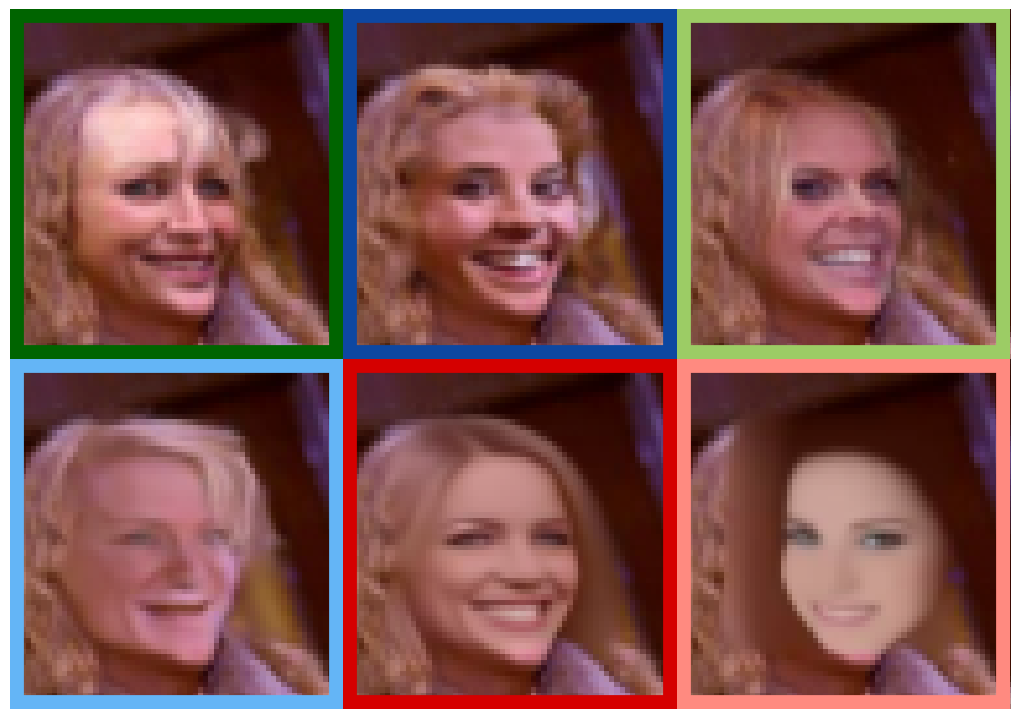

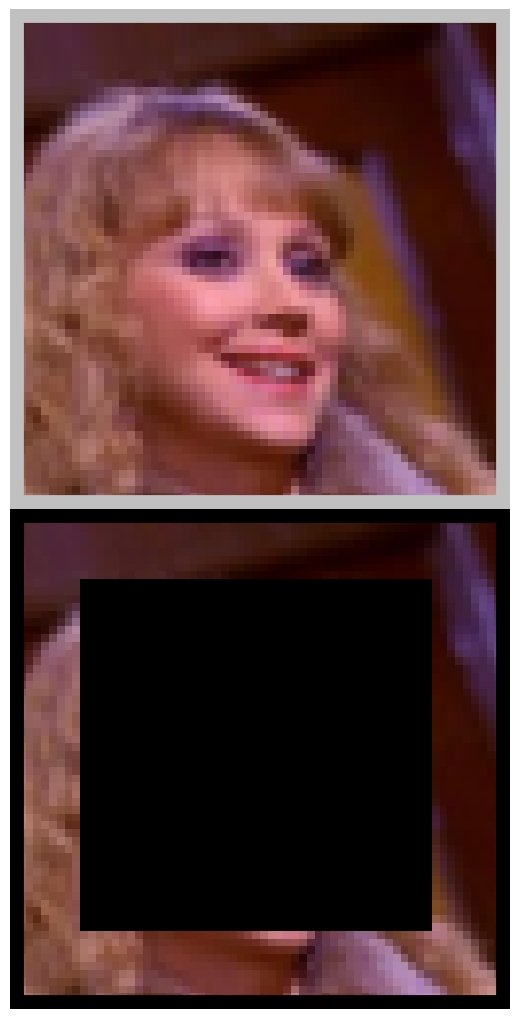

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Your updated saturated colors
colors = {
    'dps_low': '#006400',    'dps_high': '#9CCC65',
    'energy_low': '#0D47A1', 'energy_high': '#64B5F6',
    'red_low': '#D50000',    'red_high': '#FF8A80'
}

# 1. Create the figure with absolute zero spacing
fig, axes = plt.subplots(2, 3, figsize=(10, 7), 
                         gridspec_kw={'wspace': 0, 'hspace': 0})

def add_inset_border(ax, img_tensor, color):
    # Show image and immediately turn off all axis lines/spines
    ax.imshow(img_tensor.cpu().permute(1, 2, 0), aspect='auto')
    ax.axis('off')
    
    # 2. Manually draw a Rectangle that sits exactly on the edge
    # linewidth is internal, so it won't overlap adjacent images
    border = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                               linewidth=20, # Adjust thickness here
                               edgecolor=color, 
                               facecolor='none',
                               joinstyle='miter') # Ensures sharp 90-degree corners
    ax.add_patch(border)

# Row 0
add_inset_border(axes[0,0], imgs_dps[idxs_dps[-1]], colors['dps_low'])
add_inset_border(axes[0,1], imgs[idxs[-1]],         colors['energy_low'])
add_inset_border(axes[0,2], imgs_dps[idxs_dps[0]],  colors['dps_high'])

# Row 1
add_inset_border(axes[1,0], imgs[idxs[0]],         colors['energy_high'])
add_inset_border(axes[1,1], imgs_red[idxs_red[-1]], colors['red_low'])
add_inset_border(axes[1,2], imgs_red[idxs_red[0]],  colors['red_high'])

# 3. Force the subplots to fill the canvas entirely
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# 4. Save with no padding
plt.savefig("logp_x_perfect_grid.pdf", bbox_inches='tight', pad_inches=0)

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Create a figure with 2 rows, 1 column, and ABSOLUTE zero spacing
fig, axes = plt.subplots(2, 1, figsize=(5, 10), 
                         gridspec_kw={'wspace': 0, 'hspace': 0})

def add_inset_border(ax, img_tensor, color):
    # Display the image
    ax.imshow(img_tensor.cpu().permute(1, 2, 0), aspect='auto')
    ax.axis('off')
    
    # Add the Rectangle border inside the axis area
    border = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                               linewidth=20, # Matches your previous thickness
                               edgecolor=color, 
                               facecolor='none',
                               joinstyle='miter')
    ax.add_patch(border)

# Top Image: Ground Truth / x_aux with Blue box
add_inset_border(axes[0], x_aux[0], 'silver')

# Bottom Image: Reconstruction / y_ours with Black box
add_inset_border(axes[1], y_ours[0], 'black')

# 2. Force the subplots to occupy the entire figure area
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# 3. Save with zero padding for a perfectly flush look
plt.savefig("single_column_flush.pdf", bbox_inches='tight', pad_inches=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0038543316..0.80528224].


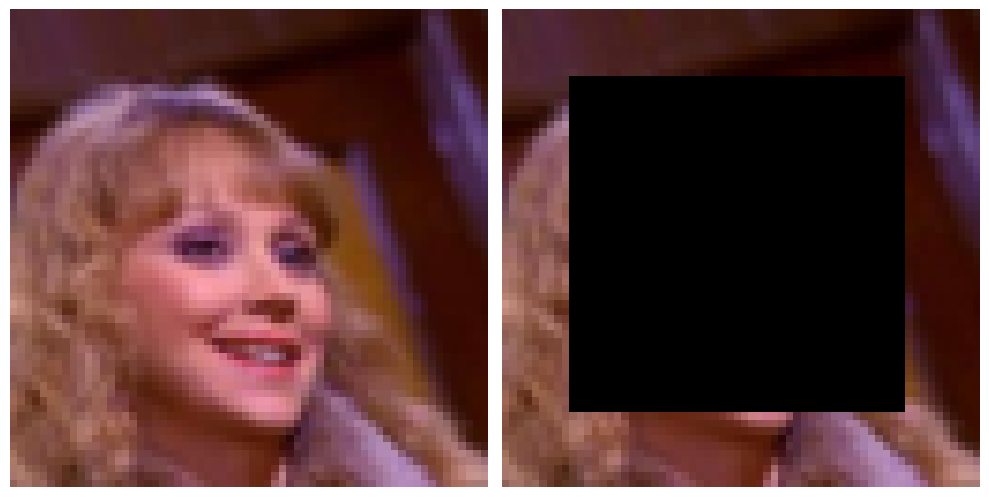

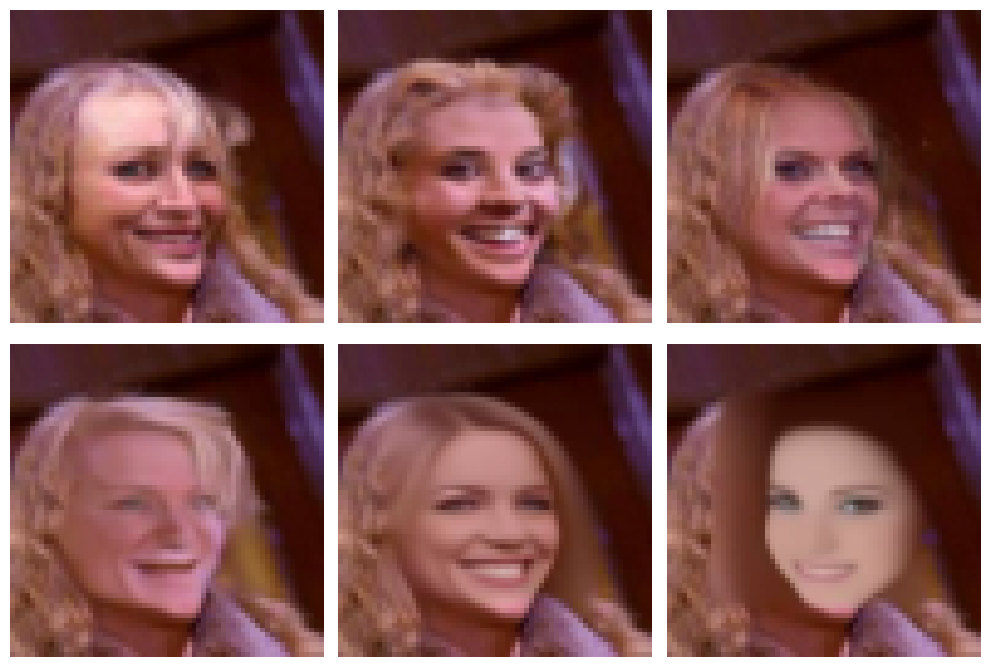

In [21]:
## fig, axes = plt.subplots(1, 3, figsize=(10, 40))
# axes[0].imshow(y_ours[0].permute(1,2,0).cpu().numpy())
# axes[1].imshow(x_hat[0].permute(1,2,0).cpu().numpy())
# axes[2].imshow(x_mod_red[0].permute(1,2,0).cpu().numpy())
# axes[0].set_title(entropy_y.mean())
# axes[1].set_title(entropy_x.mean())
# axes[2].set_title(entropy_x_red.mean())

x_aux = saved_outputs['x'][None, :, :, :].detach()
# x_true = torch.clamp(x_aux.clone() #+ 0.5e-3 * torch.randn_like(x_aux), 0, 1 )
fig, axes = plt.subplots(1, 2, figsize=(10, 7))
axes[0].imshow(x_aux[0].cpu().permute(1, 2, 0))
axes[1].imshow(y_ours[0].cpu().permute(1,2,0))
axes[0].axis('off')
axes[1].axis('off')
# axes[0].set_title("True image")
# axes[1].set_title("Ours (energy)")
# axes[2].set_title("DPS")
# axes[3].set_title("RED-Diff")
plt.tight_layout()
plt.savefig("images.pdf")

val, idxs = p_x_hat_energy.sort(descending = True) # log p
val_dps, idxs_dps = p_x_hat_dps.sort(descending = True) # log p
val_red, idxs_red = p_x_hat_red.sort(descending = True) # log p

# val, idxs = p_x_hat_energy.sort(descending = True) # log p
# val_dps, idxs_dps = p_x_hat_dps.sort(descending = True) # log p
# val_red, idxs_red = p_x_hat_red.sort(descending = True) # log p


# idx_all = -1

val, idxs = p_x_hat_energy.sort(descending = True) # log p
val_dps, idxs_dps = p_x_hat_dps.sort(descending = True) # log p
val_red, idxs_red = p_x_hat_red.sort(descending = True) # log p


# # print("Highest under log p(x|y)")
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
# fig.suptitle(r"Highest under $\log p(x|y)$", fontsize=16, y=0.65)
# axes[0].imshow(x_true[0].cpu().permute(1, 2, 0))
axes[0,1].imshow(imgs[idxs[-1], :,:,:].cpu().permute(1, 2, 0))
axes[0,0].imshow(imgs_dps[idxs_dps[-1], :,:,:].cpu().permute(1, 2, 0))
axes[0,2].imshow(imgs_dps[idxs_dps[0], :,:,:].cpu().permute(1, 2, 0))
axes[1,0].imshow(imgs[idxs[0], :,:,:].cpu().permute(1, 2, 0))
axes[1,1].imshow(imgs_red[idxs_red[-1], :,:,:].cpu().permute(1, 2, 0))
axes[1,2].imshow(imgs_red[idxs_red[0], :,:,:].cpu().permute(1, 2, 0))
axes[0,0].axis('off')
axes[0,1].axis('off')
axes[0,2].axis('off')
axes[1,0].axis('off')
axes[1,1].axis('off')
axes[1,2].axis('off')
# axes[0].set_title("True image")
# axes[1].set_title("Ours (energy)")
# axes[2].set_title("DPS")
# axes[3].set_title("RED-Diff")
plt.tight_layout()
plt.savefig("logp_x_single_img10.pdf")
# axes[0].set_title("Highest under log p(x}y)")
# axes[1,1].imshow(imgs[idxs[-1], :,:,:].cpu().permute(1, 2, 0))

# val, idxs = p_x_hat_energy.sort(descending = True) # log p
# val_dps, idxs_dps = p_x_hat_dps.sort(descending = True) # log p
# val_red, idxs_red = p_x_hat_red.sort(descending = True) # log p

# # print("Highest under log p(x)")
# fig, axes = plt.subplots(1, 4, figsize=(10, 10))
# # fig.suptitle(r"Highest under $\log p(x)$", fontsize=16, y=0.95)
# axes[0].imshow(x_true[0].cpu().permute(1, 2, 0))
# axes[1].imshow(imgs[idxs[idx_all], :,:,:].cpu().permute(1, 2, 0))
# axes[2].imshow(imgs_dps[idxs_dps[idx_all], :,:,:].cpu().permute(1, 2, 0))
# axes[3].imshow(imgs_red[idxs_red[idx_all], :,:,:].cpu().permute(1, 2, 0))
# # axes[0].set_title("True image")
# # axes[1].set_title("Ours (energy)")
# # axes[2].set_title("DPS")
# # axes[3].set_title("RED-Diff")
# axes[0].axis('off')
# axes[1].axis('off')
# # axes[2].axis('off')
# # axes[3].axis('off')
# plt.tight_layout()
# plt.savefig("highest_logp_x_single_img10.pdf")
# # fig.title("Highest under log p(x)")
# # axes[1,1].imshow(imgs[idxs[-1], :,:,:].cpu().permute(1, 2, 0))
